In [44]:
import os
import glob
import math
import random
import dendropy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from Bio import AlignIO, SeqIO, Phylo
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord


Hamming distance of original seqs VS sim seqs

In [45]:
def read_fasta(filepath):
    seqs = []
    name, seq_chars = None, []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if name is not None:
                    seqs.append("".join(seq_chars))
                name = line[1:]
                seq_chars = []
            else:
                seq_chars.append(line)
        if name is not None:
            seqs.append("".join(seq_chars))
    return seqs[0]

def hamming_distance(s1, s2):
    if len(s1) != len(s2):
        raise ValueError(f"Length mismatch: {len(s1)} vs {len(s2)}")
    return sum(a != b for a, b in zip(s1, s2))

# --- Load original/reference sequence ---
original_seq = read_fasta("/home/yutianc/sim_proj/alignment/H3_human_alignment_dates_fixed.fa") 

# --- Load all 20 sim sequences ---
files = sorted(glob.glob("/home/yutianc/sim_proj/sim_seqs/cluster/*reordered.fasta"))  
sequences = {f: read_fasta(f) for f in files}

# --- Compare each sim to the original ---
distances = []
for f, seq in sequences.items():
    d = hamming_distance(original_seq, seq)
    distances.append(d)
    print(f"{f} vs original: {d}")

# --- sum and bootstrap 95% CI ---
sum_d = sum(distances) / len(distances)

random.seed(42)
n_boot = 10000
n = len(distances)
boot_sums = [
    sum(distances[random.randrange(n)] for _ in range(n)) / n
    for _ in range(n_boot)
]
boot_sums.sort()
ci_lo = boot_sums[int(0.025 * n_boot)]
ci_hi = boot_sums[int(0.975 * n_boot)]

print(f"\nsum Hamming distance to original: {sum_d:.4f}")
print(f"95% CI: ({ci_lo:.4f}, {ci_hi:.4f})")

/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep10_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep11_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep12_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep13_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep14_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep15_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep16_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep17_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep18_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep19_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep1_reordered.fasta vs original: 268
/home/yutianc/sim_proj/sim_seqs/cluster/sim_rep20_reordered.fasta vs original: 268
/home

Pull DMS value from https://www.pnas.org/doi/10.1073/pnas.1806133115#supplementary-materials

In [14]:
pref = pd.read_csv("/home/yutianc/sim_proj/dms/replicate-2_prefs.csv")
ha_ref = SeqIO.read("/home/yutianc/bjorn/data/flu/reference_HA.fasta", format="fasta")
align = AlignIO.read("/home/yutianc/sim_proj/alignment/H3_human_alignment_dates_fixed.fa", format="fasta")


In [15]:
def translate(seq):
    aa_ls = []
    for i in range(0, len(seq), 3):
        codon = seq[i: i+3]
        try:
            aa = str(Seq(codon).translate(table=1))
        except:
            aa = "X"
        aa_ls.append(aa)
    return aa_ls

aa_dict = {}
aa_dict["ref"] = translate(str(ha_ref.seq))
for s in align:
    aa_dict[s.id] = translate(str(s.seq))


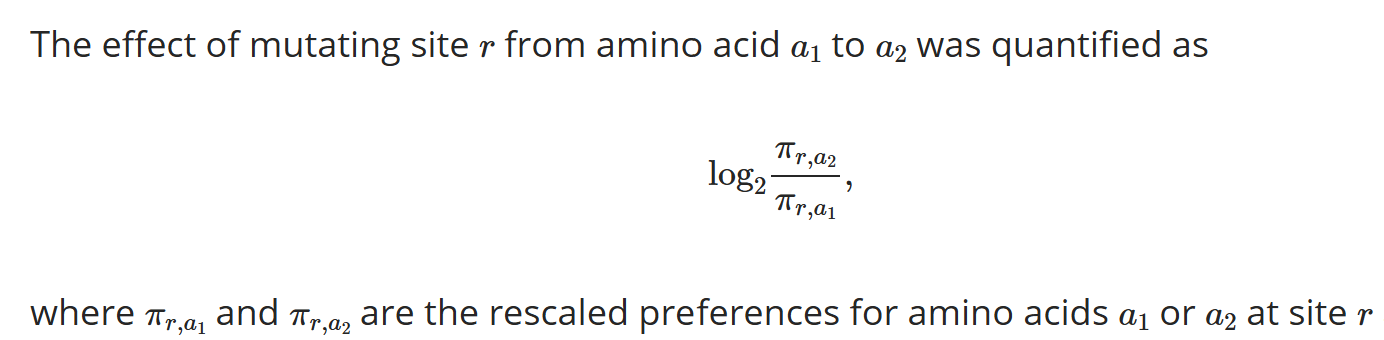

In [16]:
AA_COORDS = [1, 566]
site_dms_sum_dict = {}
site_dms_dict = {}

for site in range(AA_COORDS[0], AA_COORDS[-1] + 1):
    wt = aa_dict["ref"][site - 1]
    pi_r_a1 = pref.loc[pref["site"] == site, wt].iloc[0]  # extract scalar
    
    total = 0
    mut_effect_ls = []
    for s in align:
        mutant = aa_dict[str(s.id)][site - 1]
        pi_r_a2 = pref.loc[pref["site"] == site, mutant].iloc[0]  # extract scalar
        mut_effect = math.log2(pi_r_a2 / pi_r_a1)
        total += mut_effect
        mut_effect_ls.append(mut_effect)
    
    site_dms_sum_dict[site] = total  
    site_dms_dict[site] = mut_effect_ls


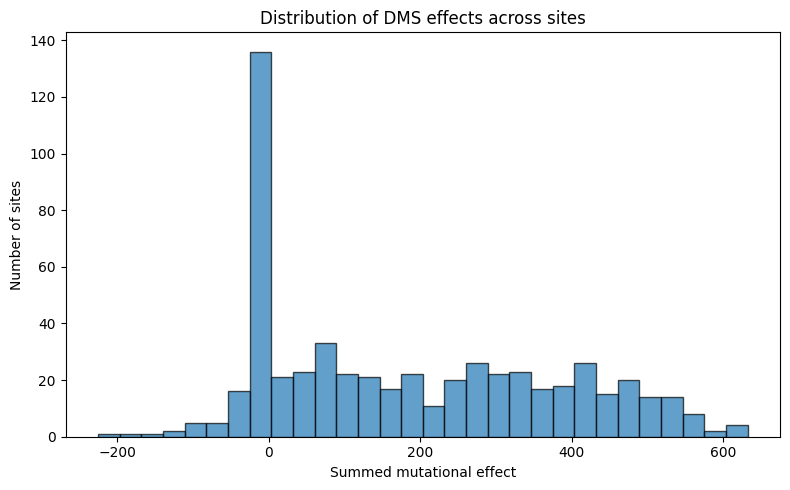

In [17]:
values = list(site_dms_sum_dict.values())

plt.figure(figsize=(8, 5))
plt.hist(values, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Summed mutational effect")
plt.ylabel("Number of sites")
plt.title("Distribution of DMS effects across sites")
plt.tight_layout()
plt.show()

In [18]:
sites = list(site_dms_dict.keys())
X = np.array([site_dms_dict[s] for s in sites])  # shape: (566, 20)

ksums = KMeans(n_clusters=3, random_state=42, n_init="auto")
site_clusters = ksums.fit_predict(X)

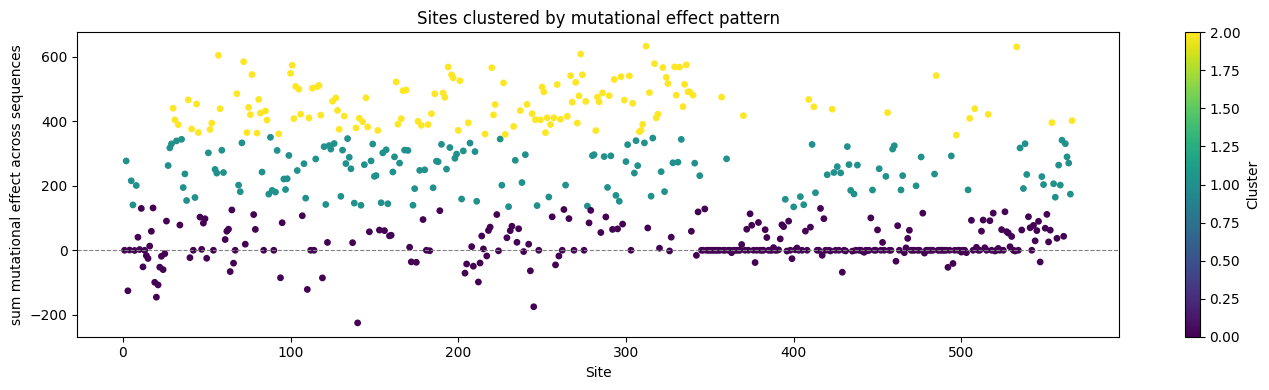

/tmp/ipykernel_611282/1574870301.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cluster_groups, labels=[f"Cluster {c}" for c in sorted(results["cluster"].unique())])


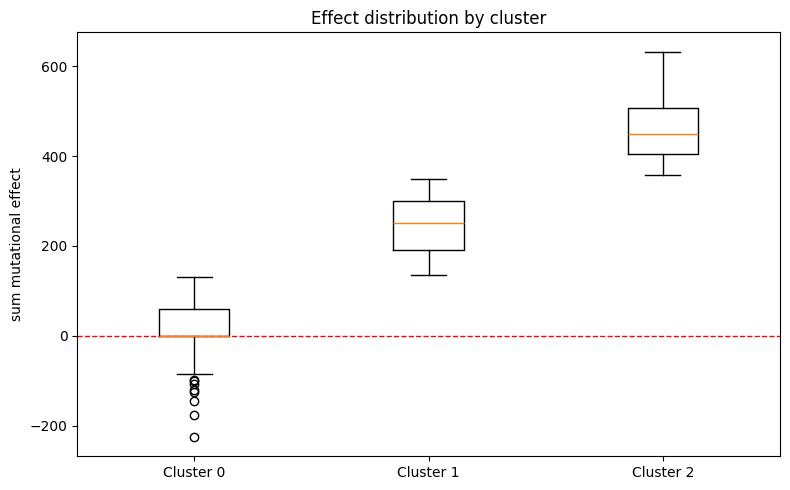

In [19]:
sites = list(site_dms_dict.keys())
X = np.array([site_dms_dict[s] for s in sites])  # shape: (566, 20)

# --- Build a results table ---
results = pd.DataFrame({
    "site": sites,
    "sum_effect": X.sum(axis=1),
    "cluster": site_clusters
})

# Order clusters by sum effect so cluster 0 = most deleterious, etc.
cluster_order = results.groupby("cluster")["sum_effect"].sum().sort_values().index
cluster_map = {old: new for new, old in enumerate(cluster_order)}
results["cluster"] = results["cluster"].map(cluster_map)

# --- 1. Scatter: site vs sum effect, colored by cluster ---
plt.figure(figsize=(14, 4))
scatter = plt.scatter(results["site"], results["sum_effect"], 
                       c=results["cluster"], cmap="viridis", s=15)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Site")
plt.ylabel("sum mutational effect across sequences")
plt.title("Sites clustered by mutational effect pattern")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

# --- 2. Boxplot: distribution of per-sequence effects within each cluster ---
plt.figure(figsize=(8, 5))
cluster_groups = [results.loc[results["cluster"] == c, "sum_effect"] 
                   for c in sorted(results["cluster"].unique())]
plt.boxplot(cluster_groups, labels=[f"Cluster {c}" for c in sorted(results["cluster"].unique())])
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.ylabel("sum mutational effect")
plt.title("Effect distribution by cluster")
plt.tight_layout()
plt.show()

# Draw lines separating clusters
cluster_bounds = results.loc

In [20]:
cluster_indices = {
    c: np.where(site_clusters == c)[0].tolist()
    for c in range(3)
}

cluster_sites = {
    c: [sites[i] for i in idxs]
    for c, idxs in cluster_indices.items()
}

In [12]:
# split the alignment files into 3 subfiles by cluster
align = AlignIO.read("/home/yutianc/sim_proj/alignment/H3_human_alignment_dates_fixed.fa", "fasta")

n_seqs = len(align)
aln_length = align.get_alignment_length()

for cluster in range(3):
    sites = cluster_sites[cluster]
    nuc_col_idx = []
    col_idx = sorted(s-1 for s in sites) # 0-based idx
    for i in col_idx:
        nuc_col_idx.extend([3 * i, 3 * i + 1, 3 * i + 2])

    new_recs = []
    for rec in align:
        seq = str(rec.seq)
        new_seq = "".join(seq[i] for i in nuc_col_idx)
        assert len(new_seq) == 3*len(sites)
        new_rec = rec[:]
        new_rec.seq = new_rec.seq.__class__(new_seq)
        new_recs.append(new_rec)

    out_path = f"/home/yutianc/sim_proj/cluster_{cluster}_alignment.fasta"
    AlignIO.write(AlignIO.MultipleSeqAlignment(new_recs), out_path, "fasta")


get root sequence for simulation

In [21]:
tree = dendropy.Tree.get(
    path="/home/yutianc/sim_proj/trees/alignment_clusters3_annotated.tree",
    schema="nexus",
    preserve_underscores=True  # important: keeps your taxon names intact, e.g. cds_AAX56510_A
)

tree.write(
    path="/home/yutianc/sim_proj/trees/alignment_clusters3_annotated.nwk",
    schema="newick"
)

print("Converted successfully.")
print(f"Number of leaf nodes: {len(tree.leaf_nodes())}")

Converted successfully.
Number of leaf nodes: 97


run treetime and get the ancestral seq

In [24]:
# Load the tree TreeTime actually wrote out
tree = Phylo.read("/home/yutianc/sim_proj/ancestral_seqs/annotated_tree.nexus", "nexus")
root = tree.root

print("Root node name:", root.name)
print("Root node comment (may contain mutation info):", root.comment)

# Now find the matching sequence in ancestral_sequences.fasta
for record in SeqIO.parse("/home/yutianc/sim_proj/ancestral_seqs/ancestral_sequences.fasta", "fasta"):
    if record.id == root.name:
        root_seq = str(record.seq)
        print(f"\nFound root sequence ({record.id}):")
        print(str(record.seq))
        print(len(str(record.seq)))
        break
else:
    print("No exact match found — root.name may be empty; see fallback below")

# construct root seqs based on cluster sites
root_cluster = {cluster: "" for cluster in range(3)}

# build nucleotide-position sets from amino-acid-position sets
nuc_cluster_sites = {}
for cluster in range(3):
    nuc_sites = set()
    for aa_site in cluster_sites[cluster]:
        nuc_start = 3 * (aa_site - 1) + 1  # 1-indexed first nt of this codon
        nuc_sites.update([nuc_start, nuc_start + 1, nuc_start + 2])
    nuc_cluster_sites[cluster] = nuc_sites

for i in range(len(root_seq)):
    for cluster in range(3):
        if i + 1 in nuc_cluster_sites[cluster]:
            root_cluster[cluster] += root_seq[i]
            break

root_cluster

Root node name: NODE_0000000
Root node comment (may contain mutation info): None

Found root sequence (NODE_0000000):
ATGAAGACCATCATTGCTTTGAGCTACATTTTCTGTCTGGCTCTCGGCCAAGACCTTCCAGGAAATGACAACAGCACAGCAACGCTGTGCCTGGGACATCATGCGGTGCCAAACGGAACACTAGTGAAAACAATCACAAATGATCAGATTGAAGTGACTAATGCTACTGAGCTAGTTCAGAGCTCCTCAACGGGGAAAATATGCAACAATCCTCATCGAATCCTTGATGGAATAGACTGCACACTGATAGATGCTCTATTGGGGGACCCTCATTGTGATGTTTTTCAAAATGAGACATGGGACCTTTTCGTTGAACGCAGCAAAGCTTTCAGCAACTGTTACCCTTATGATGTGCCAGATTATGCCTCCCTTAGGTCACTAGTTGCCTCGTCAGGCACTCTGGAGTTTATCACTGAGGGTTTCACTTGGACTGGGGTCACTCAGAATGGGGGAAGCAATGCTTGCAAAAGGGGACCTGGTAGCGGTTTTTTCAGTAGACTGAACTGGTTGACCAAATCAGGAAGCACATATCCAGTGCTGAACGTGACTATGCCAAACAATGACAATTTTGACAAACTATACATTTGGGGGGTTCACCACCCGAGCACGAACCAAGAACAAACCAGCCTGTATGTTCAAGCATCAGGGAGAGTCACAGTCTCTACCAGGAGAAGCCAGCAAACTATAATCCCGAATATCGGGTCCAGACCCTGGGTAAGGGGTCTGTCTAGTAGAATAAGCATCTATTGGACAATAGTTAAGCCGGGAGACGTACTGGTAATTAATAGTAATGGGAACCTAATCGCTCCTCGGGGTTATTTCAAAATGCGCACTGGGAAAAGCTCAATAATGAGGTCAGATGCACCTATTGATACCTGTATT

{0: 'ATGACCATCTTGTACATTTTCTGTCTGGCTCTCGGCCAAGACCTTCCAGGAAATGACAACAGCACACATACAGTGACAAATGATCAGATTAATAGCTCCTCAACGGGGAAAATACGAATAGACGATCCTGTTTTTAGCTTCAACTACCCAGCCATCGGTACTAATAAACCTGGTACCAAAAGCGTGAACACTAATAACCAAACCAGCGTTCAAGCATCAAGAGTCACAAGGAGAATACCGAATTCCAGAGTACTGTCTAGAATCGGAGTAGTAAATAGTAACGCTAAAACTGGGAGGGCAACCTCTATCAGCGTAGCAAAGCAAGTAAAACAAAGAGGCCTATTCGGTGCAATAGCAGGTTTCATAGAAGGTTGGGGAATGATAGACGGTTGGTACGGTTTCCATCAAAATTCTGAGGGCACAGGACAAGCAGCAGATCTTAAAAGCACTCAAGCAGCCATCGACCAAATCAATAAATTGAACAGGATCGAGAAGAACAAATTCCAAGAATTCTCAGAAGTAGAAAGAATTCTCAAAGTTGAAGACGATTGGTACAATGCGGAGCTTCTTGTCGCTGAGAATCAAACAATTGACGACTCGAACAAGCTGAAAACAAGGAGGCAACTGAGGAATGCTGACATGGGCAATGGTTGCTTCTACCACAAATGTGACAACGCTTGCGAGTCAAGAAATGGGACTTATGACGTATACGACGAAGCATTAAACAACCGGCAGATCAAAGGTGTTGAACTGAAGTCTGGATACAAAGACTGGATCCTGATTTTTTGCTTTTTGCTTTGTGTTGTTTTGTTCATCATGTGGAGAAGG',
 1: 'TGCCTGCATGGACTAACAATCGTGACTGAGCTATGCCATATCCTTGATGGATGCACACTGGCTCTAGATTGGGACCTTTTCGAACGCAGCTGTTATGATGTGAGGCTAGTTGCCGGCGAGTTCTGGGGGGTCAGCTTTTTCAGACTGTGGACACCAGTG

In [25]:
for c in root_cluster.keys():
    print(len(root_cluster[c]))

828
408
462


In [43]:
from Bio import SeqIO

def build_nuc_order(cluster_sites, n_clusters=3):
    """
    For each cluster, return the ordered list of nucleotide positions
    (1-indexed, in the ORIGINAL full-length sequence) that make up that
    partition -- in the SAME order used when the ancestral sequence for
    that partition was concatenated (sorted AA site order).
    """
    partition_nuc_order = {}  # cluster -> list of original nt positions, in partition order
    for cluster in range(n_clusters):
        aa_sites_sorted = sorted(cluster_sites[cluster])
        nuc_order = []
        for aa_site in aa_sites_sorted:
            nuc_start = 3 * (aa_site - 1) + 1  # 1-indexed first nt of this codon
            nuc_order.extend([nuc_start, nuc_start + 1, nuc_start + 2])
        partition_nuc_order[cluster] = nuc_order
    return partition_nuc_order


def map_seq_to_original_order(sim_seq, partition_nuc_order, partition_lengths, n_clusters=3):
    """
    sim_seq: the simulated sequence string, ordered as
             partition1 (len0 nt) + partition2 (len1 nt) + partition3 (len2 nt)...
    partition_nuc_order: output of build_nuc_order()
    partition_lengths: list of nt lengths per partition, e.g. [828, 408, 462]

    Returns: dict {original_nt_position (1-indexed): base}
    """
    assert len(sim_seq) == sum(partition_lengths), \
        f"seq length {len(sim_seq)} != sum of partition lengths {sum(partition_lengths)}"

    original_pos_to_base = {}
    offset = 0
    for cluster in range(n_clusters):
        plen = partition_lengths[cluster]
        chunk = sim_seq[offset: offset + plen]
        nuc_order = partition_nuc_order[cluster]
        assert len(chunk) == len(nuc_order), \
            f"cluster {cluster}: chunk length {len(chunk)} != nuc_order length {len(nuc_order)}"

        for base, orig_pos in zip(chunk, nuc_order):
            # print(base)
            # print(orig_pos)
            # raise Exception
            original_pos_to_base[orig_pos] = base

        offset += plen

    return original_pos_to_base


def reconstruct_full_sequence(original_pos_to_base, total_length):
    """
    Reassemble the full-length sequence string in original site order (1..total_length).
    Raises if any position is missing (coverage gap) -- helps catch bugs early.
    """
    missing = [p for p in range(1, total_length + 1) if p not in original_pos_to_base]
    if missing:
        raise ValueError(f"Missing {len(missing)} positions, e.g. {missing[:10]}")

    return "".join(original_pos_to_base[p] for p in range(1, total_length + 1))


# ---------------------------------------------------------
# Usage
# ---------------------------------------------------------

partition_lengths = [828, 408, 462]   # nt lengths of partition 1, 2, 3 (must match XML)
total_length = sum(partition_lengths)  # 1698

partition_nuc_order = build_nuc_order(cluster_sites)

sim_seq_dir = "/home/yutianc/sim_proj/sim_seqs/cluster/"

reordered_records = []
for seq in os.listdir(sim_seq_dir):
    seq_path = os.path.join(sim_seq_dir, seq)
    if os.path.isfile(seq_path):
        for record in SeqIO.parse(seq_path, "fasta"):
            sim_seq = str(record.seq)
            pos_to_base = map_seq_to_original_order(sim_seq, partition_nuc_order, partition_lengths)
            full_seq = reconstruct_full_sequence(pos_to_base, total_length)

            reordered_records.append(SeqRecord(Seq(full_seq), id=record.id, description=""))

        base, ext = os.path.splitext(seq_path)
        out_path = f"{base}_reordered{ext}"

        SeqIO.write(reordered_records, out_path, "fasta")
        print(f"Wrote {len(reordered_records)} reordered sequences to {out_path}")

Wrote 97 reordered sequences to /home/yutianc/sim_proj/sim_seqs/cluster/sim_rep18_reordered.fasta
Wrote 194 reordered sequences to /home/yutianc/sim_proj/sim_seqs/cluster/sim_rep13_reordered.fasta
Wrote 291 reordered sequences to /home/yutianc/sim_proj/sim_seqs/cluster/sim_rep20_reordered.fasta
Wrote 388 reordered sequences to /home/yutianc/sim_proj/sim_seqs/cluster/sim_rep9_reordered.fasta
Wrote 485 reordered sequences to /home/yutianc/sim_proj/sim_seqs/cluster/sim_rep17_reordered.fasta
Wrote 582 reordered sequences to /home/yutianc/sim_proj/sim_seqs/cluster/sim_rep6_reordered.fasta
Wrote 679 reordered sequences to /home/yutianc/sim_proj/sim_seqs/cluster/sim_rep5_reordered.fasta
Wrote 776 reordered sequences to /home/yutianc/sim_proj/sim_seqs/cluster/sim_rep19_reordered.fasta
Wrote 873 reordered sequences to /home/yutianc/sim_proj/sim_seqs/cluster/sim_rep16_reordered.fasta
Wrote 970 reordered sequences to /home/yutianc/sim_proj/sim_seqs/cluster/sim_rep4_reordered.fasta
Wrote 1067 reor

In [18]:
276+136+154


566

In [21]:
y='TAGCCATTGTCTTACTCACAACGTGCTACATCGCGGCAGGACATCAGGTATTGGTACATTTATGTGCTCAGTAATGCTCTGGATCACGGGGAATGAGGTTTTACCATACACTGCATCACATGTGGGCTGGTGGCGCGGCGGCACCAACAAGAC'
len(y)

153

In [10]:
114*14+102

1698